<div align="center">
<p align="center" style="width: 100%;">
    <img src="https://raw.githubusercontent.com/vlm-run/.github/refs/heads/main/profile/assets/vlm-black.svg" alt="VLM Run Logo" width="80" style="margin-bottom: -5px; color: #2e3138; vertical-align: middle; padding-right: 5px;"><br>
</p>
<p align="center"><a href="https://vlm.run"><b>Website</b></a> | <a href="https://docs.vlm.run/"><b>API Docs</b></a> | <a href="https://vlm.run/blog"><b>Blog</b></a> | <a href="https://discord.gg/AMApC2UzVY"><b>Discord</b></a>
</p>
</div>

# Migrating to Orion-2: Requests → Executions

**The migration in one line: change the function you call.** Your API key, the document, and the skill all stay the same; you're just swapping which method runs the extraction.

| | Function to call |
|---|---|
| **Old way (Requests)** | `client.document.generate(...)` |
| **New way (Executions)** | `client.agent.execute(...)` |

That's the heart of it. The only other thing that moves is the thin wrapper around each call: how you hand the document *in* and how you read the response *out*:

| Function | Document in | Response out |
|---|---|---|
| `client.document.generate` | local file path | `response.response` |
| `client.agent.execute` | uploaded `file_id` | `response.response` |

This notebook runs the **same** handwritten **physician referral form** through both, using the **same public skill** (`clinical-document-formatting`), so you can see the swap end to end. We preview the document once up top, then show the **raw response** from each. No grounding visualizations here, just the output.

**Docs:**
- [Orion 2: Code Execution](https://docs.vlm.run/agents/code-execution)
- [Ways to Use VLM Run](https://docs.vlm.run/ways-to-use-vlm-run)
- [Requests](https://docs.vlm.run/skills/usage/generation)
- [Executions](https://docs.vlm.run/skills/usage/agent)

---
## ⚙️ 1. Setup

Install the VLM Run SDK, plus `pypdfium2` (used by the SDK's own `pdf_images` helper to render the document preview).

In [1]:
!pip install vlmrun --upgrade --quiet
!pip install pypdfium2 --quiet

## 🔑 2. Load your API key

Add your `VLMRUN_API_KEY` to the Colab **Secrets** tab (🔑 icon in the left sidebar) so it persists across sessions, then load it below.

In [2]:
import os

try:
    from google.colab import userdata
    VLMRUN_API_KEY = userdata.get("VLMRUN_API_KEY")
except (ImportError, Exception):
    import getpass
    VLMRUN_API_KEY = os.getenv("VLMRUN_API_KEY") or getpass.getpass("Enter your VLM Run API key: ")

assert VLMRUN_API_KEY, "VLMRUN_API_KEY not found add it to Colab Secrets."
print("✅ API key loaded")

✅ API key loaded


## 🧩 3. The shared skill

We use one public skill, `clinical-document-formatting`, across **both** approaches. Pinning the same skill (and version) is what makes the comparison fair.

In [3]:
from vlmrun.client.types import AgentSkill

SKILL = AgentSkill(
    skill_name="clinical-document-formatting",
    skill_version="20260326-a481daf0",
)
print("Using skill:", SKILL.skill_name, SKILL.skill_version)

Using skill: clinical-document-formatting 20260326-a481daf0


## 📄 4. The document: handwritten physician referral form

Download the form once and render the first page so it's clear what's going into each call. We show it a single time here; the runs below just print their raw responses.

Downloaded → /content/handwritten-patient-referral.pdf
PDF has 1 page(s) showing page 1


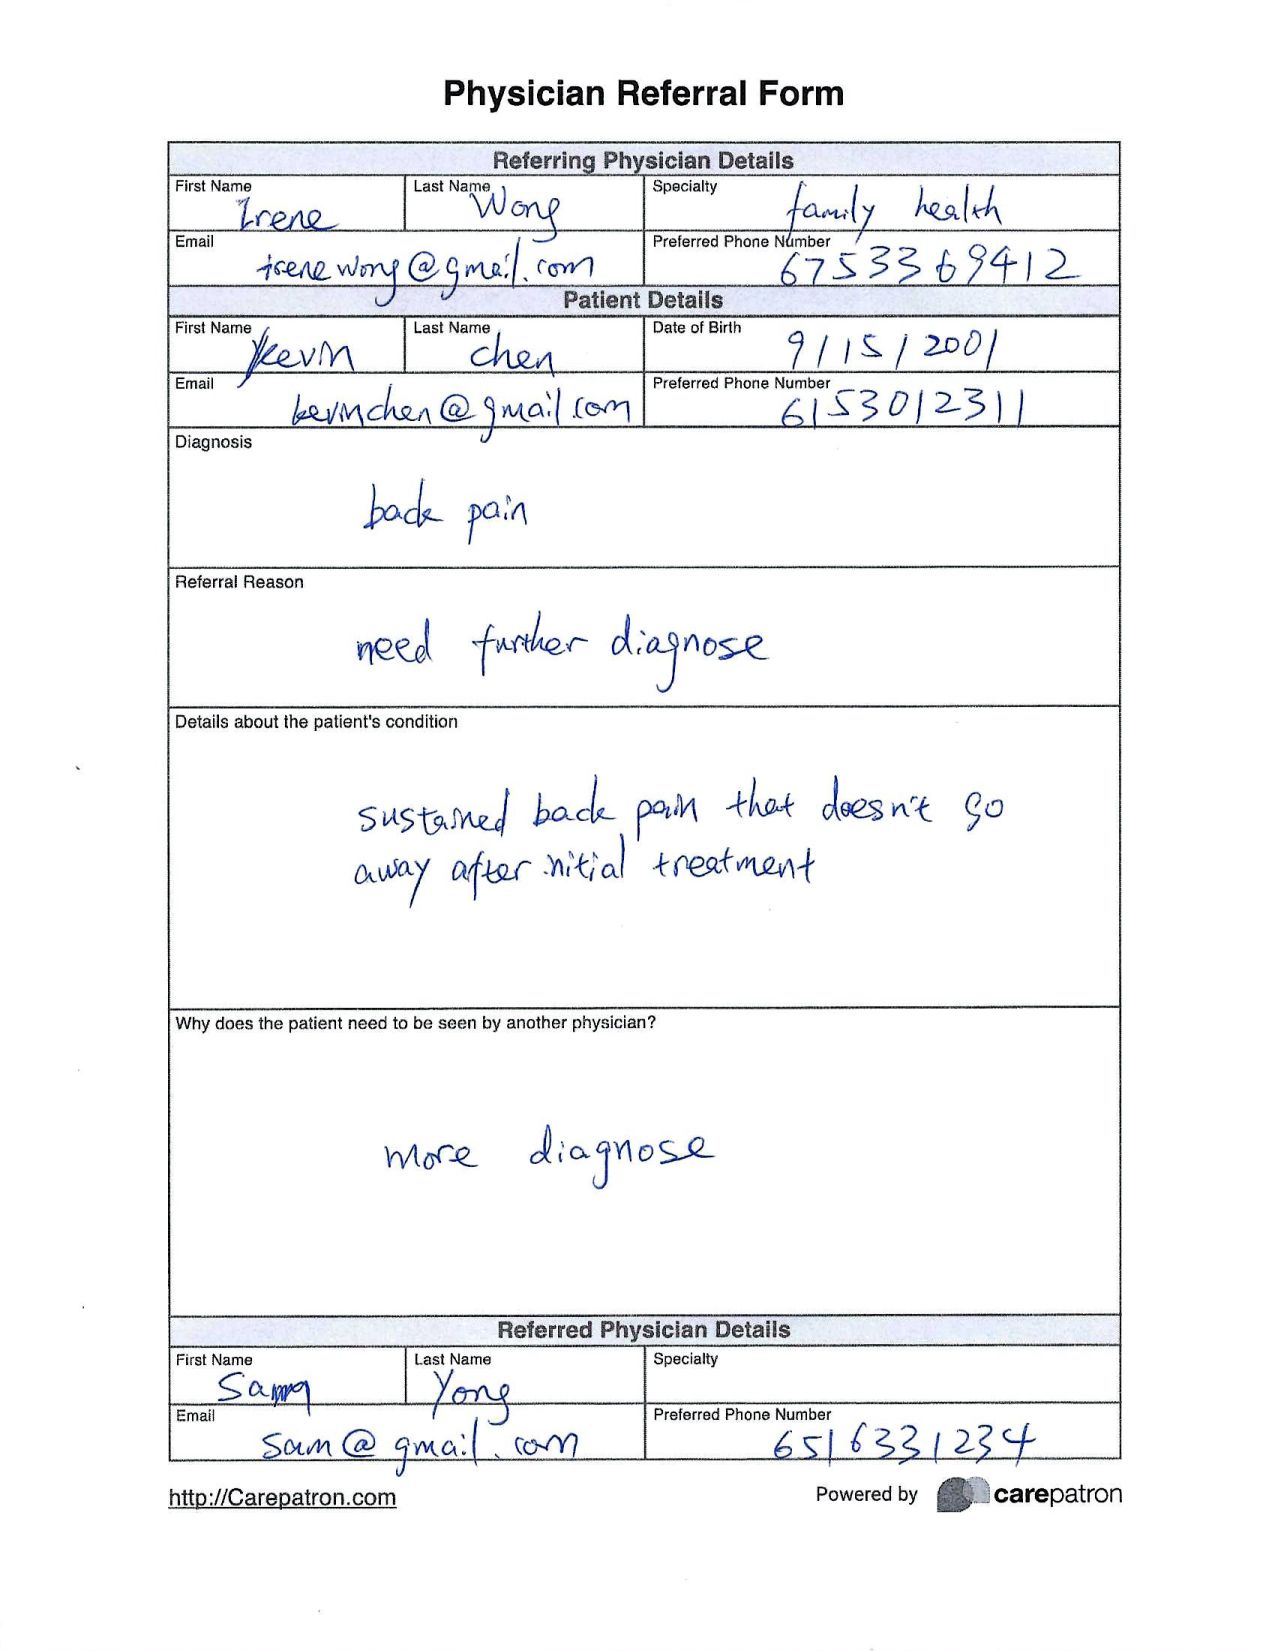

In [4]:
import requests
from pathlib import Path
from IPython.display import display
from vlmrun.common.pdf import pdf_images  # SDK helper (pypdfium2 under the hood)

REFERRAL_URL = "https://storage.googleapis.com/vlm-data-public-prod/hub/examples/healthcare.patient-referral/handwritten-patient-referral.pdf"
PDF_PATH = Path("/content/handwritten-patient-referral.pdf")
PDF_PATH.write_bytes(requests.get(REFERRAL_URL).content)
print(f"Downloaded → {PDF_PATH}")

pdf_pages = list(pdf_images(PDF_PATH, dpi=150))
print(f"PDF has {len(pdf_pages)} page(s) showing page 1")
display(pdf_pages[0].image)

---
## 🕰️ 5. The old way: Requests

First, set up the **Requests** client. This is the classic API, hosted at `api.vlm.run` (the SDK's default), used by `document.generate`.

In [5]:
from vlmrun.client import VLMRun

# One default client (api.vlm.run) handles all three surfaces
client = VLMRun(api_key=VLMRUN_API_KEY)
print("✅ Client ready → api.vlm.run")

✅ Client ready → api.vlm.run


Now run the extraction: call `client.document.generate` with the skill attached via `GenerationConfig`. Requests run in **batch mode**: `generate` hands back a job, and `predictions.wait` blocks until the prediction is ready. The result lives on `response.response`.

In [6]:
from vlmrun.client.types import GenerationConfig
from IPython.display import JSON

response = client.document.generate(
    file=PDF_PATH,
    config=GenerationConfig(skills=[SKILL]),
)

# Requests are async wait for the prediction to complete
response = client.predictions.wait(response.id)
print("✅ Status:", response.status)
JSON(response.response)

✅ Status: completed


<IPython.core.display.JSON object>

In [7]:
from IPython.display import display, Markdown

markdown_payload = response.response.get("markdown_content") if response.response else None

if markdown_payload:
    display(Markdown(markdown_payload))
else:
    print("No markdown returned.")

# Physician Referral Form

## Referring Physician Details
- **First Name:** Irene
- **Last Name:** Wong
- **Specialty:** Family Health
- **Email:** irenewong@gmail.com
- **Preferred Phone Number:** 6753369412

## Patient Details
- **First Name:** Kevin
- **Last Name:** Chen
- **Date of Birth:** 9/15/2001
- **Email:** kevinchen@gmail.com
- **Preferred Phone Number:** 6153012311

## Diagnosis
- **Diagnosis:** back pain

## Referral Reason
- **Reason:** need further diagnose

## Details about the patient's condition
- sustained back pain that doesn't go away after initial treatment

## Why does the patient need to be seen by another physician?
- more diagnose

## Referred Physician Details
- **First Name:** Sam
- **Last Name:** Yong
- **Email:** sam@gmail.com
- **Preferred Phone Number:** 6516331234

Powered by carepatron

---
## ✨ 6. The new way: Orion-2

Same `client`, no setup changes. The default endpoint serves the Orion-2 agent surface too. From here the only things that change are the **function you call** (`agent.execute`) and the **`vlmrun-orion-2:auto`** model.

### Agent Executions

Upload the file via the Files API, then run a structured **execution** with the skill attached. `batch=True` kicks it off asynchronously; `executions.wait` blocks until it finishes. We show the **raw response payload**.

In [8]:
from pydantic import BaseModel, Field
from vlmrun.types import MessageContent
from vlmrun.client.types import AgentExecutionConfig, AgentExecutionResponse

class FileInput(BaseModel):
    file: MessageContent = Field(..., description="The file to process")

# Upload the document via the Files API
uploaded_file = client.files.upload(file=PDF_PATH)
print(f"Uploaded file ID: {uploaded_file.id}")

# Kick off the execution with the skill attached
response: AgentExecutionResponse = client.agent.execute(
    model="vlmrun-orion-2:auto",
    inputs=FileInput(
        file=MessageContent(type="input_file", file_id=uploaded_file.id),
    ),
    config=AgentExecutionConfig(skills=[SKILL]),
    batch=True,
)
print(f"Execution ID: {response.id} | status: {response.status}")

Uploaded file ID: bea05e4d-ffde-4b04-bba3-4266935db70b
Execution ID: a395937e-f2e9-4622-8cb3-c2c3fc292961 | status: enqueued


In [9]:
from IPython.display import JSON

# Wait for completion and show the raw response
response = client.executions.wait(response.id, timeout=180)
print("✅ Status:", response.status)
JSON(response.response) if response.response else print("None")

✅ Status: completed


<IPython.core.display.JSON object>

In [10]:
from IPython.display import display, Markdown

markdown_payload = response.response.get("markdown_content") if response.response else None

if markdown_payload:
    display(Markdown(markdown_payload))
else:
    print("No markdown returned.")

# Physician Referral Form

## Referring Physician Details

| Field | Information |
|-------|-------------|
| First Name | Irene |
| Last Name | Wong |
| Specialty | Family Health |
| Email | isrenewong@gmail.com |
| Phone | 675-336-9412 |

## Patient Details

| Field | Information |
|-------|-------------|
| First Name | Kevin |
| Last Name | Chen |
| Date of Birth | 09/15/2001 |
| Email | kevinchen@gmail.com |
| Phone | 615-301-2311 |

## Clinical Information

### Diagnosis
- Back pain

### Referral Reason
- Need further diagnose

### Details About Patient's Condition
- Sustained back pain that doesn't go away after initial treatment

### Reason for Referral
- More diagnose

## Referred Physician Details

| Field | Information |
|-------|-------------|
| First Name | Sam |
| Last Name | Yong |
| Email | sam@gmail.com |
| Phone | 651-633-1234 |
| Specialty | Not specified |

---

### Clinical Summary

This is a referral form from Dr. Irene Wong (Family Health) for patient **Kevin Chen** (DOB: 09/15/2001). The patient presents with **sustained back pain** that has not resolved with initial treatment. Dr. Wong is referring the patient to **Dr. Sam Yong** for further diagnostic evaluation and additional diagnosis. No lab results or medication information were documented in this referral form.


---
## 📋 7. Summary migrating from Requests to Executions

| | Old way | New way · Executions |
|---|---|---|
| **Call** | `client.document.generate` | `client.agent.execute` |
| **Model** | `vlm-1` | `vlmrun-orion-2:auto` |
| **Input** | local file path | uploaded `file_id` |
| **Style** | batch + `predictions.wait` | batch + `executions.wait` |
| **Skill** | `clinical-document-formatting` | `clinical-document-formatting` |
| **Read result** | `response.response` | `response.response` |

Same document, same skill, two interfaces. Executions are a good fit for structured, batchable jobs and are the recommended path forward from Requests.